라이브러리 로드

In [1]:
# Import or install Sionna
import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import drjit as dr
import mitsuba as mi
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import tensorflow as tf
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import plotly.graph_objects as go

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
    
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, ITURadioMaterial,\
    Camera, PathSolver, InteractionType, RadioMapSolver
from sionna.rt.utils import r_hat

import importlib
import js_utils as js
js = importlib.reload(js)

no_preview = False # Toggle to False to use the preview widget

2026-02-25 14:12:54.904794: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-25 14:12:54.917976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771996374.932627 2616394 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771996374.937397 2616394 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771996374.948810 2616394 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

1. Scene XML 파일 로드 및 재질 확인

In [2]:
# XML 파일 경로 보정 및 로드
xml_path = "/home/js/js/sionna-rt/src/sionna/rt/scenes/etri/etri_260224_flat.xml"
scene_dir = os.path.dirname(xml_path)

scene = load_scene(xml_path, merge_shapes=False)
scene.frequency = 28e9
# 재질(Material) 정보 확인
js.print_scene_materials(scene)


Object Name                    | Assigned Material   
None_forest_001                | itu_wood            
None_forest_002                | itu_wood            
None_buildings_002-plasterboard | itu_plasterboard    
None_buildings_002-plasterboard-001 | itu_plasterboard    
None_buildings_001-plasterboard.003 | itu_plasterboard    
None_buildings_001-plasterboard | itu_plasterboard    
None_vegetation                | itu_glass           
None_forest_003                | itu_wood            
None_vegetation_002            | itu_glass           
None_vegetation_001            | itu_glass           
None_vegetation_003            | itu_glass           
elm__3                         | itu_concrete        
elm__5                         | itu_concrete        
elm__7                         | itu_concrete        

[정의된 재질 목록]
 - 이름: itu_wood        (Type: wood, Thickness: [0.1])
 - 이름: itu_plasterboard (Type: plasterboard, Thickness: [0.1])
 - 이름: itu_glass       (Type: glass, Thickness:

2. 도로 재질 변경

In [3]:
red_road_mat = ITURadioMaterial(name="red_road_mat_7",
                                itu_type="concrete",
                                thickness=0.2,
                                color=[1.0, 0.0, 0.0])
scene.add(red_road_mat)

road_object_id = "elm__7"

if road_object_id in scene.objects:
    scene.objects[road_object_id].radio_material = red_road_mat
    print(f"[설정] 도로({road_object_id})를 빨간색으로 변경했습니다.")

[설정] 도로(elm__7)를 빨간색으로 변경했습니다.


3. 도로 정점 추출

In [4]:
road_object_id = "elm__7"
road_positions = js.get_road_positions_from_object(
    scene,
    road_object_id,
    dtype=np.float16,       # 한글 주석: 연산용 기본 타입
    round_decimals=3,       # 한글 주석: 화면 표시 자릿수만 줄임
)

if len(road_positions) == 0:
    print("[안내] 추출된 좌표가 없습니다.")
else:
    print("dtype:", road_positions.dtype)
    print("first road position:", road_positions[0])

[탐색] Mitsuba Scene 내부에서 'elm__7' 형상을 찾습니다...
  -> 추출된 도로 좌표 수: 26개 (dtype=float16)
dtype: float16
first road position: [ 2.098e+01 -3.148e+02  3.000e-01]


4. 초기 위치 테스트

In [5]:
# 설정 및 초기화
target_pos = road_positions[0]
print("="*60 + f"\n[설정] 테스트 목표: {target_pos}\n" + "="*60)

# 장치 배치
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="VH")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="VH")

tx_positions = [[2.294, -279.590, 11]]#, [323.472, 36.869, -204.315], [0.663, 56.367, -181.453]]
tx_names = ["Tx_1"]#, "Tx_2", "Tx_3"]

# 기존 객체 제거
for name in tx_names + ['Car_Marker']:
    if name in scene.transmitters: scene.remove(name)
if 'rx_car' in scene.receivers: scene.remove('rx_car')

for i, pos in enumerate(tx_positions):
    tx = Transmitter(name=tx_names[i], position=pos, power_dbm=43)
    tx.transmit_antenna = scene.tx_array
    tx.look_at(target_pos)
    scene.add(tx)
    print(f" -> {tx_names[i]} 배치 완료.")

rx = Receiver(name="rx_car", position=target_pos)
rx.receive_antenna = scene.rx_array
scene.add(rx)
print(" -> 자동차(Rx) 배치 완료.")

# 시뮬레이션
print("[연산] 경로 계산 시작...")
solver = PathSolver()
paths = solver(scene, max_depth=5, samples_per_src=1000000, diffuse_reflection=True, diffraction=True)

# 시각화
cam = Camera(position=target_pos + np.array([0, 100, 100]), look_at=target_pos)
print("[시각화] 3D 뷰어 실행")
scene.preview(paths=paths, show_devices=True)

[설정] 테스트 목표: [ 2.098e+01 -3.148e+02  3.000e-01]
 -> Tx_1 배치 완료.
 -> 자동차(Rx) 배치 완료.
[연산] 경로 계산 시작...
[시각화] 3D 뷰어 실행


***메인 시뮬레이션***

경로 준비

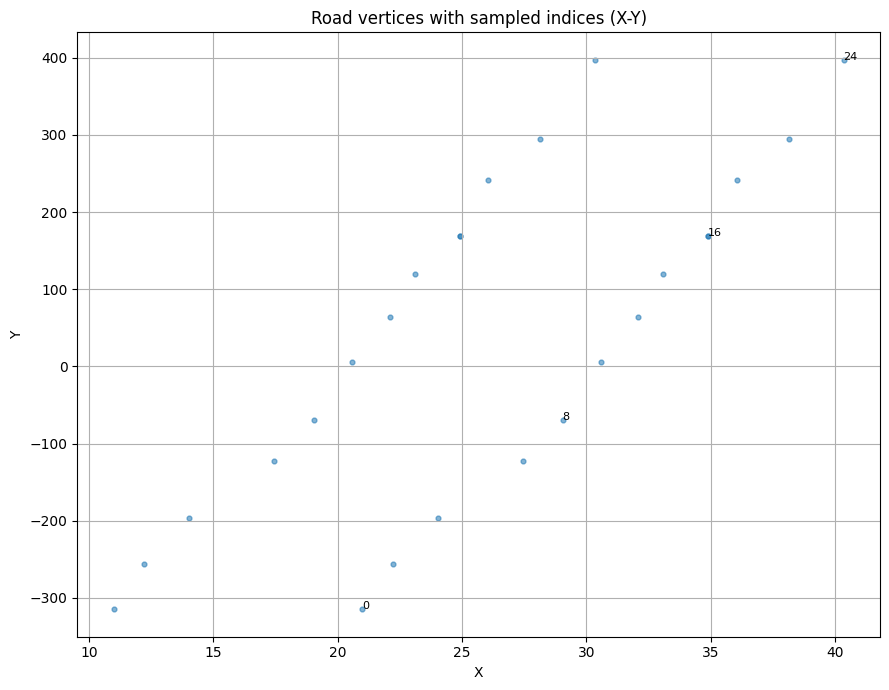

In [6]:
# 한글 주석: 먼저 XY에서 정점 인덱스 분포를 확인
js.plot_vertices_xy_with_indices(
    road_positions=road_positions,
    step=8,          # 한글 주석: 숫자가 작을수록 더 많은 인덱스를 표시
    figsize=(9, 7),
)

In [7]:
# 한글 주석: 위 Cell 에서 본 인덱스를 직접 입력

start_idx = 22
end_idx = 7

path_data = js.prepare_vehicle_path(
    road_positions=road_positions,
    path_indices=None,
    use_centerline=True,
    centerline_points=60,
    start_index=start_idx,
    end_index=end_idx,
    y_offset=2,
    speed_ms=100.0 / 3.6,
    delta_t=0.5,
)

print("waypoints:", path_data["waypoints"].shape)
print(f"총 거리: {path_data['total_distance']:.2f} m")

waypoints: (8, 3)
총 거리: 417.40 m


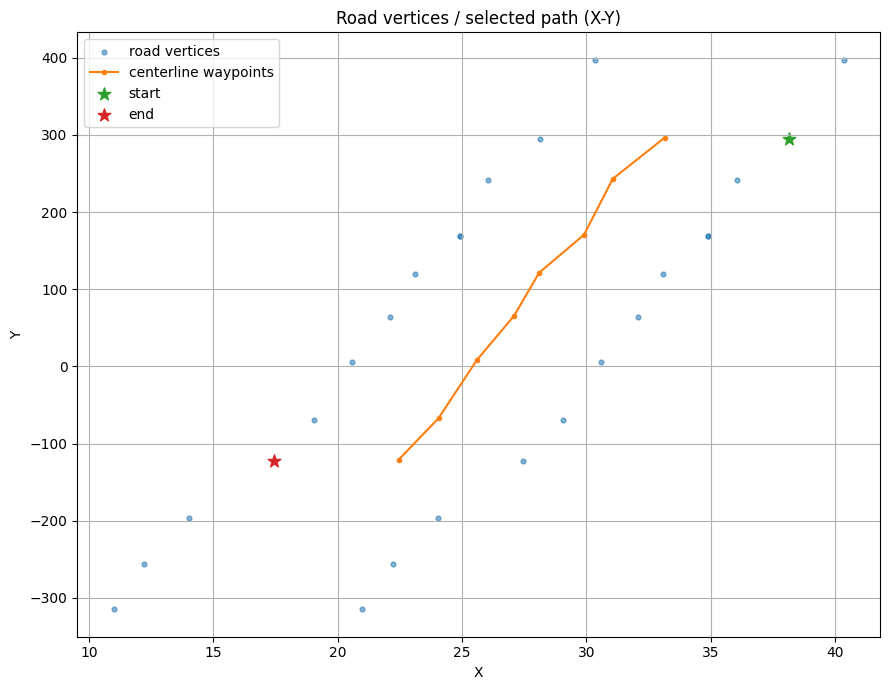

In [8]:
js.plot_vertices_xy(
    road_positions=road_positions,
    waypoints=path_data["waypoints"],
    start_point=road_positions[start_idx],
    end_point=road_positions[end_idx],
    figsize=(9, 7),
)

Scene 초기화 (Tx/Rx + Solver)

In [9]:
tx_names, rx, solver = js.setup_scene_for_vehicle_path(
    scene=scene,
    path_data=path_data,
    tx_positions=tx_positions,
    tx_names=tx_names,
    tx_power_dbm=43.0,
    display_radius=20.0
)

start_pos, start_vel = js.get_state_at_time(path_data, 0.0)
print("초기 위치:", np.round(start_pos, 3))
print("초기 속도:", np.round(start_vel, 3))

초기 위치: [ 33.148 296.375   0.3  ]
초기 속도: [ -1.085 -27.757   0.   ]


Interactive 위젯 실행

In [10]:
slider, output_widget = js.create_vehicle_simulation_widgets(
    scene=scene,
    path_data=path_data,
    tx_names=tx_names,
    rx=rx,
    solver=solver,
    max_depth=3,
    max_num_paths_per_src=100000,
    samples_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
    resolution=(800, 600),
)

print("▼ 슬라이더를 움직여보세요.")
display(slider, output_widget)

▼ 슬라이더를 움직여보세요.


IntSlider(value=0, description='Time Step:', layout=Layout(width='600px'), max=31)

Output()

CIR 측정

In [11]:
# 1. 이전 셀 등에서 미리 만들어둔 경로 데이터를 불러옵니다.
# path_data = prepare_vehicle_path(road_positions, speed_ms=60/3.6, use_centerline=True)

# 2. path_data 안에서 시간축 배열(time_steps)을 꺼내옵니다.
time_steps = path_data["time_steps"]

frame_idx = 0  # 보고 싶은 프레임 인덱스 (원하는 값으로 바꿔)
t = time_steps[frame_idx]

# 3. get_pos_at_time 대신 좀 전에 만든 get_state_at_time을 사용하여 위치와 속도를 동시에 가져옵니다.
current_pos, current_vel = js.get_state_at_time(path_data, t)

# 4. 위치/방향 업데이트 (속도까지 업데이트 해주는 것이 도플러 효과에 좋습니다!)
rx.position = current_pos
rx.velocity = current_vel

for name in tx_names:
    scene.transmitters[name].look_at(current_pos)

# 5. 경로 계산
paths = solver(scene, max_depth=3, samples_per_src=100000,
               diffuse_reflection=True, diffraction=True, synthetic_array=True)

# 6. CIR 추출
a, tau = paths.cir(out_type="tf", normalize_delays=False)

print("t =", t)
print("a shape:", a.shape)
print("tau shape:", tau.shape)


t = 0.0
a shape: (1, 2, 1, 2, 1, 1)
tau shape: (1, 1, 1)


jit_flush_malloc_cache(): Dr.Jit exhausted the available memory and had to flush its allocation cache to free up additional memory. This is an expensive operation and will have a negative effect on performance. You may want to change your computation so that it uses less memory. This warning will only be displayed once.


CIR 시각화

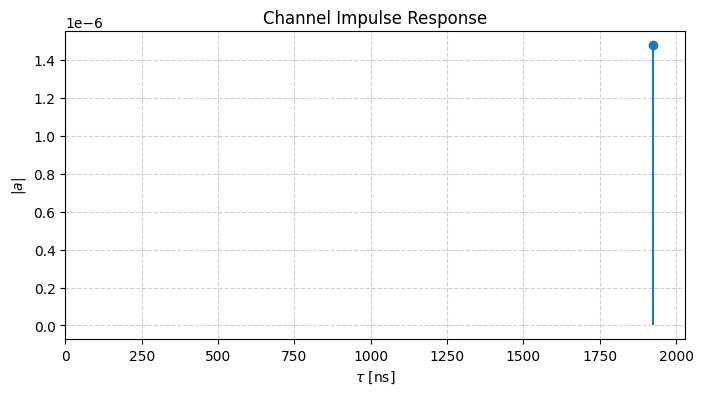

In [ ]:
# 모양(shape)이 [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths] 인 경우 (5차원)
t = tau[0, 0, :] / 1e-9            # tau는 주로 [rx, tx, path] 형태
# (참고: 버전에 따라 tau도 a와 차원이 같을 수 있으니 안 맞으면 tau[0, 0, 0, 0, :] 로 수정)
a_abs = np.abs(a)[0, 0, 0, 0, :, 0]

# --- 그래프 그리기 ---
plt.figure(figsize=(8, 4))
plt.title("Channel Impulse Response")
plt.stem(t, a_abs, basefmt=" ")
plt.xlim(left=0)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [12]:
# 계산 결과 캐시: (frame_idx, tx_idx, rel_delay) -> (t, pos, df)
_pdp_cache = {}

out = widgets.Output()

tx_dropdown = widgets.Dropdown(
    options=[("Tx_1", 0)],#, ("Tx_2", 1), ("Tx_3", 2)],
    value=0,
    description="TX:",
    layout=widgets.Layout(width="200px")
)

frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(time_steps)-1,
    step=1,
    description="Time:",
    continuous_update=False,
    layout=widgets.Layout(width="600px")
)

# 0부터 시작하는 상대지연으로 볼지 옵션 (원하면 켜기)
rel_delay_chk = widgets.Checkbox(
    value=False,
    description="Relative delay (min τ = 0)",
    indent=False
)

def _compute_mapping_for_frame(frame_idx: int, tx_idx: int, rel_delay: bool):
    key = (frame_idx, tx_idx, rel_delay)
    if key in _pdp_cache:
        return _pdp_cache[key]

    t = float(time_steps[frame_idx])
    pos, vel = js.get_state_at_time(path_data,t)

    # 위치/방향 업데이트
    rx.position = pos
    rx.velocity = vel
    for name in tx_names:
        scene.transmitters[name].look_at(pos)

    # 경로 계산
    paths = solver(
        scene,
        max_depth=3,
        samples_per_src=100000,
        diffuse_reflection=True,
        diffraction=True,
        synthetic_array=True
    )

    # CIR 추출 (절대 지연)
    a, tau = paths.cir(out_type="tf", normalize_delays=False)

    # 너 케이스 기준:
    # a: (1, 2, 3, 128, P, 1)
    # tau: (1, 3, P)
    tau_tx = tau[0, tx_idx, :]  

    # PDP: Rx편파(2) + Tx포트(128) 합산 -> (P,)
    pdp = tf.reduce_sum(tf.abs(a[0, :, tx_idx, :, :, 0])**2, axis=[0, 1])  # (P,)

    # ---------------------------
    # padding/가짜 경로 제거
    #   - tau가 음수(-1 같은)면 padding일 가능성이 큼
    # ---------------------------
    valid = tf.math.is_finite(tau_tx) & (tau_tx >= 0)
    idx_valid = tf.where(valid)[:, 0]  # (P_valid,)

    if tf.size(idx_valid) == 0:
        # 유효 경로 없음
        df = pd.DataFrame(columns=["path_idx", "tau_ns", "pdp_db"])
        _pdp_cache[key] = (t, pos, df)
        return _pdp_cache[key]

    tau_v = tf.boolean_mask(tau_tx, valid)   # (P_valid,)
    pdp_v = tf.boolean_mask(pdp, valid)      # (P_valid,)

    # 상대지연 옵션: min τ를 0으로 이동
    if rel_delay:
        tau_v = tau_v - tf.reduce_min(tau_v)

    # 지연 기준 정렬
    order = tf.argsort(tau_v)
    tau_s = tf.gather(tau_v, order).numpy() * 1e9  # ns
    pdp_s = tf.gather(pdp_v, order).numpy()
    pdp_db = 10*np.log10(pdp_s + 1e-30)

    # 정렬된 path_idx (원래 인덱스 기준)
    path_idx_sorted = tf.gather(idx_valid, order).numpy()


    df = pd.DataFrame({
        "path_idx": path_idx_sorted.astype(int),
        "tau_ns": tau_s,
        "pdp_db": pdp_db
        })

    _pdp_cache[key] = (t, pos, df)
    return _pdp_cache[key]

def _update_plot(_=None):
    frame_idx = frame_slider.value
    tx_idx = tx_dropdown.value
    rel_delay = rel_delay_chk.value

    with out:
        out.clear_output(wait=True)

        t, pos, df = _compute_mapping_for_frame(frame_idx, tx_idx, rel_delay)

        if df.empty:
            print(f"t={t:.2f}s | frame={frame_idx} | Tx_{tx_idx+1} : 유효 경로가 없습니다 (완전 차폐/패딩 제거 후 0개).")
            print(f"pos={pos}")
            return

        # 1) 매핑 테이블 출력 (path_idx ↔ 임펄스)
        display(df)

        # 2) CIR(PDP) stem + 라벨(path_idx)
        plt.figure(figsize=(8, 3.6))
        plt.stem(df["tau_ns"].values, df["pdp_db"].values, basefmt=" ")

        # 라벨: 각 임펄스 위에 path_idx
        for x, y, pid in zip(df["tau_ns"].values, df["pdp_db"].values, df["path_idx"].values):
            plt.text(x, y, str(pid), fontsize=9, ha="center", va="bottom")

        plt.xlabel("Delay τ (ns)")
        plt.ylabel("Power (dB)")
        plt.title(f"Tx_{tx_idx+1} PDP at t={t:.2f}s | frame={frame_idx}\npos={pos}")
        plt.grid(True)
        plt.show()

# 이벤트 연결
frame_slider.observe(_update_plot, names="value")
tx_dropdown.observe(_update_plot, names="value")
rel_delay_chk.observe(_update_plot, names="value")

display(widgets.VBox([widgets.HBox([frame_slider, tx_dropdown]), rel_delay_chk]), out)
_update_plot()

Output()

In [13]:
# 한글 주석: taps 설정값
bandwidth = 500e6          # 채널 대역폭 [Hz]
l_min, l_max = 0, 1500     # 탭 인덱스 범위
sampling_frequency = 10e4         # 시간축 샘플링 주파수 [Hz]
num_time_steps = 16       # 시간 샘플 수(도플러 반영)

In [14]:
# 한글 주석: 캐시 (frame_idx, tx_idx, rel_delay) -> (t, pos, df)
_taps_cache = {}

out = widgets.Output()

tx_dropdown = widgets.Dropdown(
    options=[(name, i) for i, name in enumerate(tx_names)],
    value=0,
    description="TX:",
    layout=widgets.Layout(width="220px")
)

frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(time_steps)-1,
    step=1,
    description="Time:",
    continuous_update=False,
    layout=widgets.Layout(width="600px")
)

rel_delay_chk = widgets.Checkbox(
    value=False,
    description="Relative delay (min τ = 0)",
    indent=False
)

def _compute_taps_for_frame(frame_idx: int, tx_idx: int, rel_delay: bool):
    key = (frame_idx, tx_idx, rel_delay)
    if key in _taps_cache:
        return _taps_cache[key]

    t = float(time_steps[frame_idx])
    pos, vel = js.get_state_at_time(path_data,t)

    # 한글 주석: Rx 위치/방향 갱신
    rx.position = pos
    rx.velocity = vel
    for name in tx_names:
        scene.transmitters[name].look_at(pos)

    # 한글 주석: 경로 계산
    paths = solver(
        scene,
        max_depth=3,
        samples_per_src=100000,
        diffuse_reflection=True,
        diffraction=True,
        synthetic_array=True
    )

    # 한글 주석: taps 계산 (TF 텐서)
    h = paths.taps(
        bandwidth=bandwidth,
        l_min=l_min,
        l_max=l_max,
        sampling_frequency=sampling_frequency,
        num_time_steps=num_time_steps,
        normalize=False,
        normalize_delays=False,
        out_type="tf"
    )
    # 기대 shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_taps]

    # 한글 주석: Rx=0, 선택 Tx, time=0에서 안테나 축 합산해 PDP 생성
    h_sel = h[0, :, tx_idx, :, 0, :]                         # [num_rx_ant, num_tx_ant, num_taps]
    pdp = tf.reduce_sum(tf.abs(h_sel)**2, axis=[0, 1])       # [num_taps]
    pdp_np = pdp.numpy()

    tap_idx = np.arange(l_min, l_max + 1, dtype=int)
    tau_ns = (tap_idx / bandwidth) * 1e9                     # τ = l / W

    valid = np.isfinite(pdp_np) & (pdp_np > 0)
    if np.sum(valid) == 0:
        df = pd.DataFrame(columns=["tap_idx", "tau_ns", "pdp_db"])
        _taps_cache[key] = (t, pos, df)
        return _taps_cache[key]

    tap_v = tap_idx[valid]
    tau_v = tau_ns[valid]
    pdp_v = pdp_np[valid]

    if rel_delay:
        tau_v = tau_v - np.min(tau_v)

    order = np.argsort(tau_v)
    tap_s = tap_v[order]
    tau_s = tau_v[order]
    pdp_db = 10*np.log10(pdp_v[order] + 1e-30)

    df = pd.DataFrame({
        "tap_idx": tap_s.astype(int),
        "tau_ns": tau_s,
        "pdp_db": pdp_db
    })

    _taps_cache[key] = (t, pos, df)
    return _taps_cache[key]

def _update_plot(_=None):
    frame_idx = frame_slider.value
    tx_idx = tx_dropdown.value
    rel_delay = rel_delay_chk.value

    with out:
        out.clear_output(wait=True)

        t, pos, df = _compute_taps_for_frame(frame_idx, tx_idx, rel_delay)

        if df.empty:
            print(f"t={t:.2f}s | frame={frame_idx} | {tx_names[tx_idx]} : 유효 탭이 없습니다.")
            print(f"pos={pos}")
            return

        # 한글 주석: 테이블 출력
        display(df)

        # 한글 주석: taps 기반 PDP stem
        plt.figure(figsize=(8, 3.6))
        plt.stem(df["tau_ns"].values, df["pdp_db"].values, basefmt=" ")
        for x, y, tap in zip(df["tau_ns"].values, df["pdp_db"].values, df["tap_idx"].values):
            plt.text(x, y, str(tap), fontsize=9, ha="center", va="bottom")

        plt.xlabel("Delay τ (ns)")
        plt.ylabel("Power (dB)")
        plt.title(f"{tx_names[tx_idx]} taps-PDP at t={t:.2f}s | frame={frame_idx}\npos={pos}")
        plt.grid(True)
        plt.show()

# 한글 주석: 위젯 이벤트 연결
frame_slider.observe(_update_plot, names="value")
tx_dropdown.observe(_update_plot, names="value")
rel_delay_chk.observe(_update_plot, names="value")

display(widgets.VBox([widgets.HBox([frame_slider, tx_dropdown]), rel_delay_chk]), out)
_update_plot()

Output()